
# Comparación de modelos a partir de un JSON de resultados

Este notebook carga un JSON con la estructura:

- metadatos del experimento (`timestamp`, `dataset`, `total_samples`, `models_evaluated`)
- una lista `results` con un bloque por modelo
- métricas agregadas por modelo, por ejemplo:
  - `error_rate`
  - `avg_time_per_sample`
  - `rouge1`, `rouge2`, `rougeL`
  - `rouge1_std`, `rouge2_std`, `rougeL_std`
  - `bertscore_p`, `bertscore_r`, `bertscore_f1`
  - `bertscore_f1_std`

## Qué genera
1. Tabla resumen de métricas.
2. Gráfico principal de calidad: **ROUGE-L** y **BERTScore F1** con barras de error.
3. Gráfico comparativo de **ROUGE-1 / ROUGE-2 / ROUGE-L**.
4. Gráfico comparativo de **BERTScore P / R / F1**.
5. Gráfico de **tiempo promedio por muestra**.
6. Gráfico de **tasa de error**.
7. Gráfico de **estabilidad** (desviaciones estándar).
8. Gráfico de **trade-off calidad vs tiempo**.
9. **Mapa de calor normalizado** para comparación global.
10. **Ranking compuesto opcional** con pesos editables.

> Nota: si el archivo JSON está truncado o mal cerrado, el notebook lo detecta y muestra un error claro.


In [3]:

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)


In [4]:

# Cambia esta ruta si tu JSON está en otro lugar.
JSON_PATH = Path("generation_results_20260402_204218.json")

# Si quieres guardar automáticamente las figuras:
SAVE_FIGURES = False
FIGURES_DIR = Path("figures_model_comparison")


In [5]:

def load_experiment_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")

    text = path.read_text(encoding="utf-8")

    try:
        data = json.loads(text)
    except json.JSONDecodeError as e:
        line = e.lineno
        col = e.colno
        excerpt_start = max(0, e.pos - 120)
        excerpt_end = min(len(text), e.pos + 120)
        excerpt = text[excerpt_start:excerpt_end]

        raise ValueError(
            "El archivo no es un JSON válido. "
            "Posibles causas: archivo truncado, comas faltantes o cierre incompleto de llaves/corchetes.\n"
            f"Error de parseo en línea {line}, columna {col}.\n"
            f"Fragmento cercano al error:\n{excerpt}"
        ) from e

    required_top_keys = {"results"}
    missing_top = required_top_keys - set(data.keys())
    if missing_top:
        raise KeyError(f"Faltan claves obligatorias en el nivel superior: {missing_top}")

    if not isinstance(data["results"], list) or len(data["results"]) == 0:
        raise ValueError("La clave 'results' debe ser una lista no vacía.")

    return data


def build_metrics_df(data: dict) -> pd.DataFrame:
    metric_columns = [
        "model_name",
        "params",
        "samples_evaluated",
        "error_count",
        "error_rate",
        "total_time_s",
        "avg_time_per_sample",
        "rouge1",
        "rouge2",
        "rougeL",
        "rouge1_std",
        "rouge2_std",
        "rougeL_std",
        "bertscore_p",
        "bertscore_r",
        "bertscore_f1",
        "bertscore_f1_std",
    ]

    rows = []
    for result in data["results"]:
        row = {col: result.get(col, np.nan) for col in metric_columns}
        row["predictions_count"] = len(result.get("predictions", [])) if isinstance(result.get("predictions"), list) else 0
        rows.append(row)

    df = pd.DataFrame(rows)

    # Conversión de columnas numéricas
    numeric_cols = [c for c in df.columns if c not in ["model_name", "params"]]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def shorten_name(name: str) -> str:
    mapping = {
        "Llama-3.1-8B-Instruct": "Llama 3.1 8B",
        "Qwen2.5-7B-Instruct": "Qwen2.5 7B",
        "Gemma-2-9B-it": "Gemma 2 9B",
        "FLAN-T5-large": "FLAN-T5 large",
        "FLAN-T5-base": "FLAN-T5 base",
        "Zephyr-7B": "Zephyr 7B",
    }
    return mapping.get(name, name)


def add_value_labels(ax, fmt="{:.3f}", rotation=0, fontsize=9):
    for p in ax.patches:
        height = p.get_height()
        if np.isnan(height):
            continue
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            textcoords="offset points",
            xytext=(0, 3),
            rotation=rotation,
            fontsize=fontsize,
        )


def save_current_figure(name: str):
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / name, bbox_inches="tight", dpi=200)


data = load_experiment_json(JSON_PATH)
df = build_metrics_df(data)

df["model_short"] = df["model_name"].apply(shorten_name)

# Orden base para casi todas las figuras: mejor BERTScore F1 primero.
df = df.sort_values(by="bertscore_f1", ascending=False).reset_index(drop=True)

print("Dataset:", data.get("dataset", "N/D"))
print("Timestamp:", data.get("timestamp", "N/D"))
print("Total samples:", data.get("total_samples", "N/D"))
print("Modelos en el JSON:", len(df))
df[["model_name", "params", "samples_evaluated", "predictions_count"]]


Dataset: D:\tesis\Agent\dataset_v2.csv
Timestamp: 20260402_204218
Total samples: 100
Modelos en el JSON: 6


,model_name,params,samples_evaluated,predictions_count
0,Qwen2.5-7B-Instruct,7B,100,100
1,Llama-3.1-8B-Instruct,8B,100,9
2,Gemma-2-9B-it,9B,100,100
3,Zephyr-7B,7B,100,9
4,FLAN-T5-large,780M,100,100
5,FLAN-T5-base,250M,100,100


## Tabla resumen de métricas

In [6]:

summary_cols = [
    "model_name",
    "params",
    "samples_evaluated",
    "error_rate",
    "avg_time_per_sample",
    "rouge1",
    "rouge2",
    "rougeL",
    "bertscore_p",
    "bertscore_r",
    "bertscore_f1",
    "rougeL_std",
    "bertscore_f1_std",
]

summary_df = df[summary_cols].copy()
summary_df


,model_name,params,samples_evaluated,error_rate,avg_time_per_sample,rouge1,rouge2,rougeL,bertscore_p,bertscore_r,bertscore_f1,rougeL_std,bertscore_f1_std
0,Qwen2.5-7B-Instruct,7B,100,0.0,3.9320,0.8924,0.8340,0.8841,0.9857,0.9902,0.9879,0.1388,0.0152
1,Llama-3.1-8B-Instruct,8B,100,0.0,28.8456,0.7556,0.6996,0.7442,0.9672,0.9741,0.9705,0.2064,0.0239
2,Gemma-2-9B-it,9B,100,0.0,34.4527,0.7059,0.6250,0.6796,0.9637,0.9557,0.9596,0.1529,0.0171
3,Zephyr-7B,7B,100,0.0,17.5503,0.4113,0.3389,0.3747,0.8875,0.9658,0.9243,0.1884,0.0299
4,FLAN-T5-large,780M,100,0.0,13.0584,0.0939,0.0359,0.0900,0.8293,0.8277,0.8277,0.1535,0.0371
5,FLAN-T5-base,250M,100,0.0,7.9867,0.0030,0.0006,0.0027,0.8484,0.7992,0.8229,0.0183,0.0170


## 1) Gráfico principal de calidad: ROUGE-L y BERTScore F1

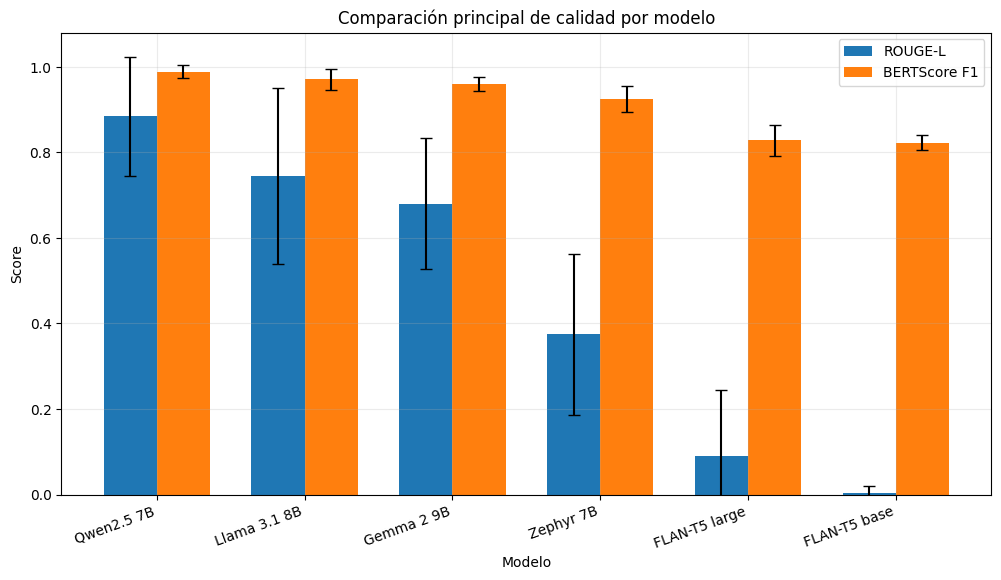

In [7]:

plot_df = df.copy()
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x - width / 2,
    plot_df["rougeL"],
    width,
    yerr=plot_df["rougeL_std"],
    capsize=4,
    label="ROUGE-L",
)
ax.bar(
    x + width / 2,
    plot_df["bertscore_f1"],
    width,
    yerr=plot_df["bertscore_f1_std"],
    capsize=4,
    label="BERTScore F1",
)

ax.set_title("Comparación principal de calidad por modelo")
ax.set_xlabel("Modelo")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_short"], rotation=20, ha="right")
ax.set_ylim(0, 1.08)
ax.legend()
save_current_figure("01_quality_main_rougel_bertscoref1.png")
plt.show()


## 2) Comparación detallada de métricas ROUGE

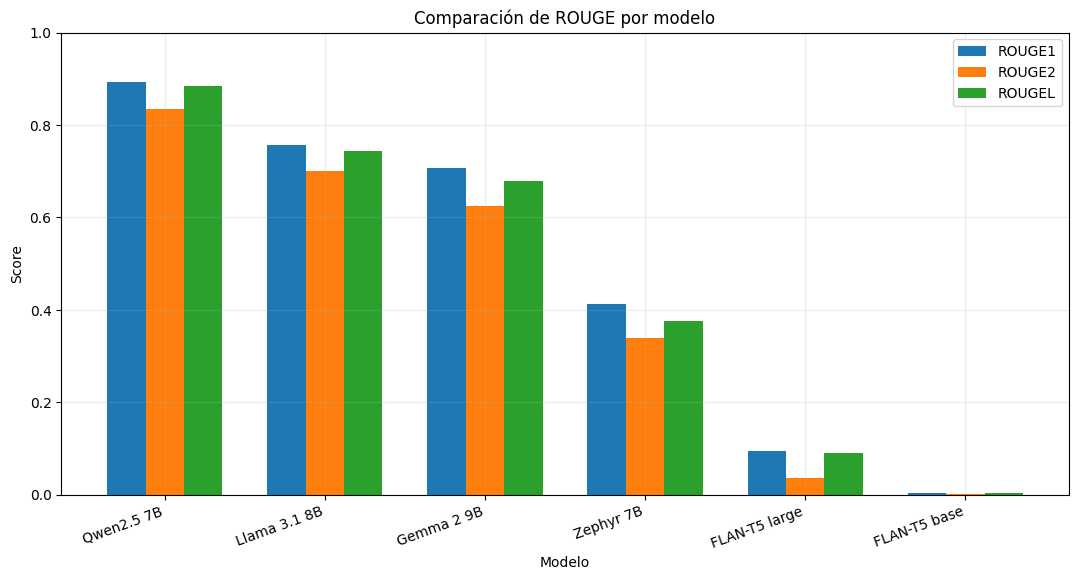

In [8]:

plot_df = df.copy()
metrics = ["rouge1", "rouge2", "rougeL"]
x = np.arange(len(plot_df))
width = 0.24

fig, ax = plt.subplots(figsize=(13, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + (i - 1) * width, plot_df[metric], width, label=metric.upper())

ax.set_title("Comparación de ROUGE por modelo")
ax.set_xlabel("Modelo")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_short"], rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.legend()
save_current_figure("02_rouge_comparison.png")
plt.show()


## 3) Comparación detallada de BERTScore

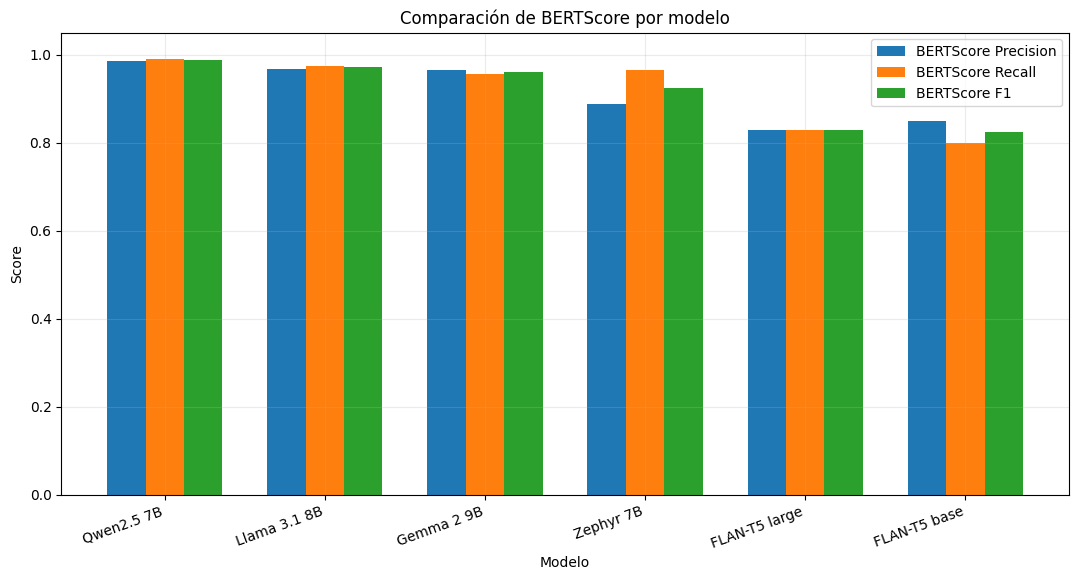

In [9]:

plot_df = df.copy()
metrics = ["bertscore_p", "bertscore_r", "bertscore_f1"]
labels = ["BERTScore Precision", "BERTScore Recall", "BERTScore F1"]
x = np.arange(len(plot_df))
width = 0.24

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, label) in enumerate(zip(metrics, labels)):
    ax.bar(x + (i - 1) * width, plot_df[metric], width, label=label)

ax.set_title("Comparación de BERTScore por modelo")
ax.set_xlabel("Modelo")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_short"], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
save_current_figure("03_bertscore_comparison.png")
plt.show()


## 4) Eficiencia: tiempo promedio por muestra

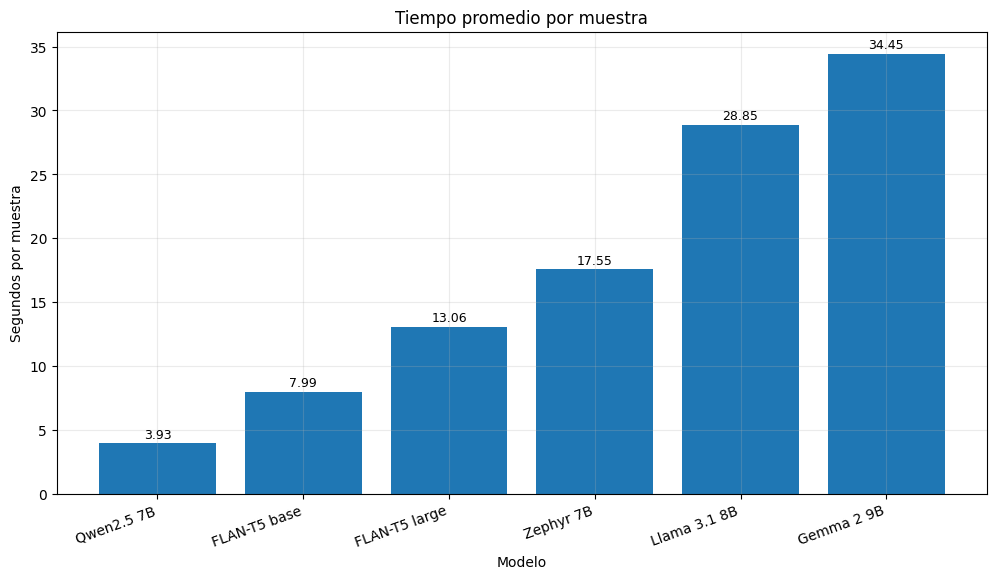

In [10]:

plot_df = df.sort_values(by="avg_time_per_sample", ascending=True).reset_index(drop=True)
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x, plot_df["avg_time_per_sample"])
ax.set_title("Tiempo promedio por muestra")
ax.set_xlabel("Modelo")
ax.set_ylabel("Segundos por muestra")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_short"], rotation=20, ha="right")

for idx, value in enumerate(plot_df["avg_time_per_sample"]):
    ax.annotate(f"{value:.2f}", (idx, value), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)

save_current_figure("04_avg_time_per_sample.png")
plt.show()


## 6) Estabilidad: desviaciones estándar

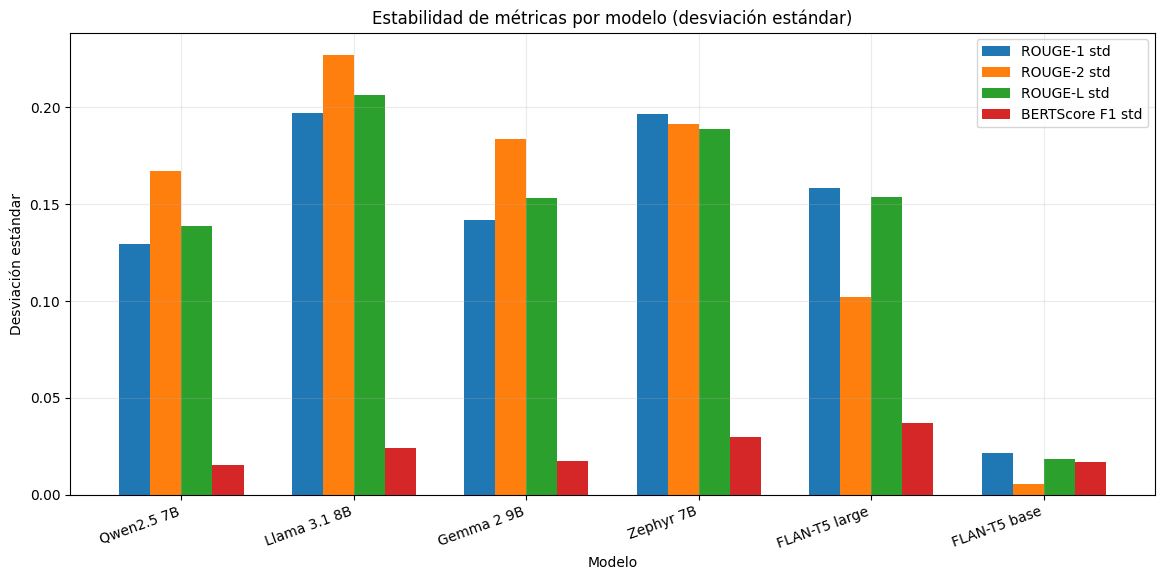

In [12]:

plot_df = df.copy()
metrics = ["rouge1_std", "rouge2_std", "rougeL_std", "bertscore_f1_std"]
labels = ["ROUGE-1 std", "ROUGE-2 std", "ROUGE-L std", "BERTScore F1 std"]
x = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, label) in enumerate(zip(metrics, labels)):
    ax.bar(x + (i - 1.5) * width, plot_df[metric], width, label=label)

ax.set_title("Estabilidad de métricas por modelo (desviación estándar)")
ax.set_xlabel("Modelo")
ax.set_ylabel("Desviación estándar")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_short"], rotation=20, ha="right")
ax.legend()
save_current_figure("06_metric_stability_std.png")
plt.show()


## 7) Trade-off: calidad semántica vs tiempo

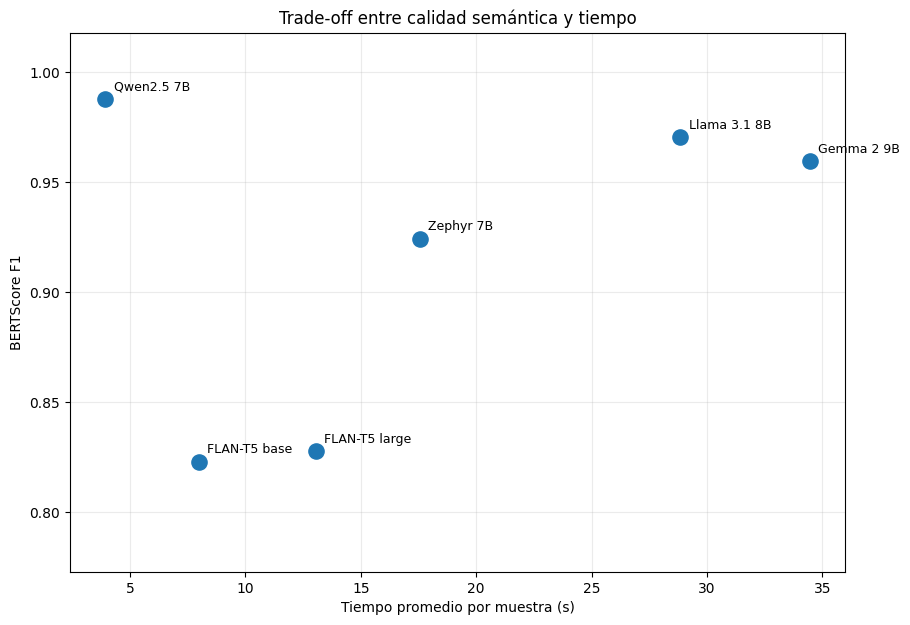

In [13]:

plot_df = df.copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(plot_df["avg_time_per_sample"], plot_df["bertscore_f1"], s=120)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["model_short"],
        (row["avg_time_per_sample"], row["bertscore_f1"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

ax.set_title("Trade-off entre calidad semántica y tiempo")
ax.set_xlabel("Tiempo promedio por muestra (s)")
ax.set_ylabel("BERTScore F1")
ax.set_ylim(
    max(0, plot_df["bertscore_f1"].min() - 0.05),
    min(1.02, plot_df["bertscore_f1"].max() + 0.03),
)
save_current_figure("07_tradeoff_time_vs_bertscoref1.png")
plt.show()


## 8) Heatmap comparativo normalizado

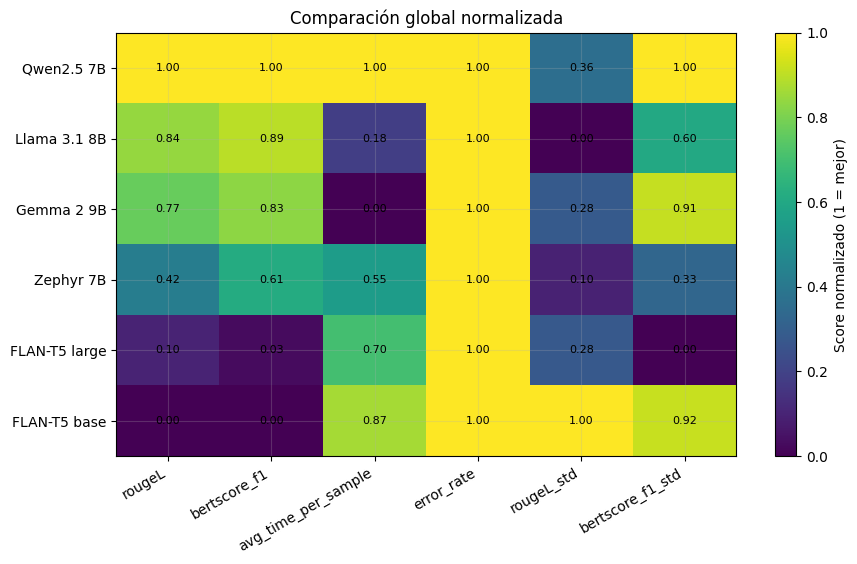

In [14]:

heatmap_metrics = [
    "rougeL",
    "bertscore_f1",
    "avg_time_per_sample",
    "error_rate",
    "rougeL_std",
    "bertscore_f1_std",
]

heatmap_df = df[["model_short"] + heatmap_metrics].copy()

# Normalización min-max orientada al "más alto es mejor"
# Para tiempo, error_rate y desviaciones estándar: menor es mejor.
higher_better = {
    "rougeL": True,
    "bertscore_f1": True,
    "avg_time_per_sample": False,
    "error_rate": False,
    "rougeL_std": False,
    "bertscore_f1_std": False,
}

norm_df = heatmap_df.copy()

for metric in heatmap_metrics:
    values = norm_df[metric].astype(float)
    vmin, vmax = values.min(), values.max()

    if math.isclose(vmin, vmax):
        norm_values = pd.Series([1.0] * len(values), index=values.index)
    else:
        norm_values = (values - vmin) / (vmax - vmin)
        if not higher_better[metric]:
            norm_values = 1 - norm_values

    norm_df[metric] = norm_values

heatmap_matrix = norm_df[heatmap_metrics].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(heatmap_matrix, aspect="auto")

ax.set_title("Comparación global normalizada")
ax.set_xticks(np.arange(len(heatmap_metrics)))
ax.set_xticklabels(heatmap_metrics, rotation=30, ha="right")
ax.set_yticks(np.arange(len(norm_df)))
ax.set_yticklabels(norm_df["model_short"])

for i in range(heatmap_matrix.shape[0]):
    for j in range(heatmap_matrix.shape[1]):
        ax.text(j, i, f"{heatmap_matrix[i, j]:.2f}", ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Score normalizado (1 = mejor)")
save_current_figure("08_normalized_heatmap.png")
plt.show()


## 9) Ranking compuesto opcional con pesos editables

In [15]:

# Ajusta estos pesos según tu criterio metodológico.
weights = {
    "rougeL": 0.30,
    "bertscore_f1": 0.40,
    "avg_time_per_sample": 0.15,
    "error_rate": 0.10,
    "rougeL_std": 0.03,
    "bertscore_f1_std": 0.02,
}

# Reutiliza la tabla normalizada del heatmap.
ranking_df = norm_df.copy()

ranking_df["composite_score"] = 0.0
for metric, weight in weights.items():
    ranking_df["composite_score"] += ranking_df[metric] * weight

ranking_df = ranking_df.sort_values(by="composite_score", ascending=False).reset_index(drop=True)

ranking_df[["model_short", "composite_score"] + list(weights.keys())]


,model_short,composite_score,rougeL,bertscore_f1,avg_time_per_sample,error_rate,rougeL_std,bertscore_f1_std
0,Qwen2.5 7B,0.9808,1.0000,1.0000,1.0000,1.0,0.3594,1.0000
1,Llama 3.1 8B,0.7498,0.8413,0.8945,0.1837,1.0,0.0000,0.6027
2,Gemma 2 9B,0.6886,0.7680,0.8285,0.0000,1.0,0.2844,0.9132
3,Zephyr 7B,0.5650,0.4221,0.6145,0.5538,1.0,0.0957,0.3288
4,FLAN-T5 base,0.2784,0.0000,0.0000,0.8671,1.0,1.0000,0.9178
5,FLAN-T5 large,0.2549,0.0990,0.0291,0.7010,1.0,0.2812,0.0000


## 10) Ranking compuesto en gráfico

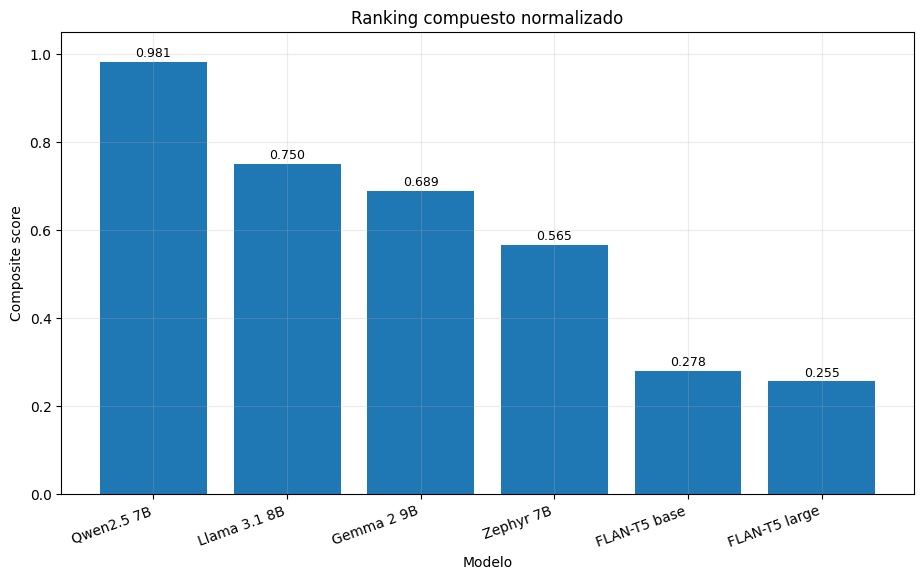

In [16]:

plot_df = ranking_df.copy()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x, plot_df["composite_score"])
ax.set_title("Ranking compuesto normalizado")
ax.set_xlabel("Modelo")
ax.set_ylabel("Composite score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_short"], rotation=20, ha="right")
ax.set_ylim(0, 1.05)

for idx, value in enumerate(plot_df["composite_score"]):
    ax.annotate(f"{value:.3f}", (idx, value), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)

save_current_figure("09_composite_ranking.png")
plt.show()


## 11) Exportar tablas procesadas

In [ ]:

EXPORT_TABLES = False

if EXPORT_TABLES:
    summary_df.to_csv("summary_metrics.csv", index=False)
    norm_df.to_csv("normalized_metrics.csv", index=False)
    ranking_df.to_csv("ranking_metrics.csv", index=False)
    print("Tablas exportadas en el directorio actual.")
else:
    print("EXPORT_TABLES=False. Cambia a True si quieres guardar CSV.")
